# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

3) Построение softmax-классификатора

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



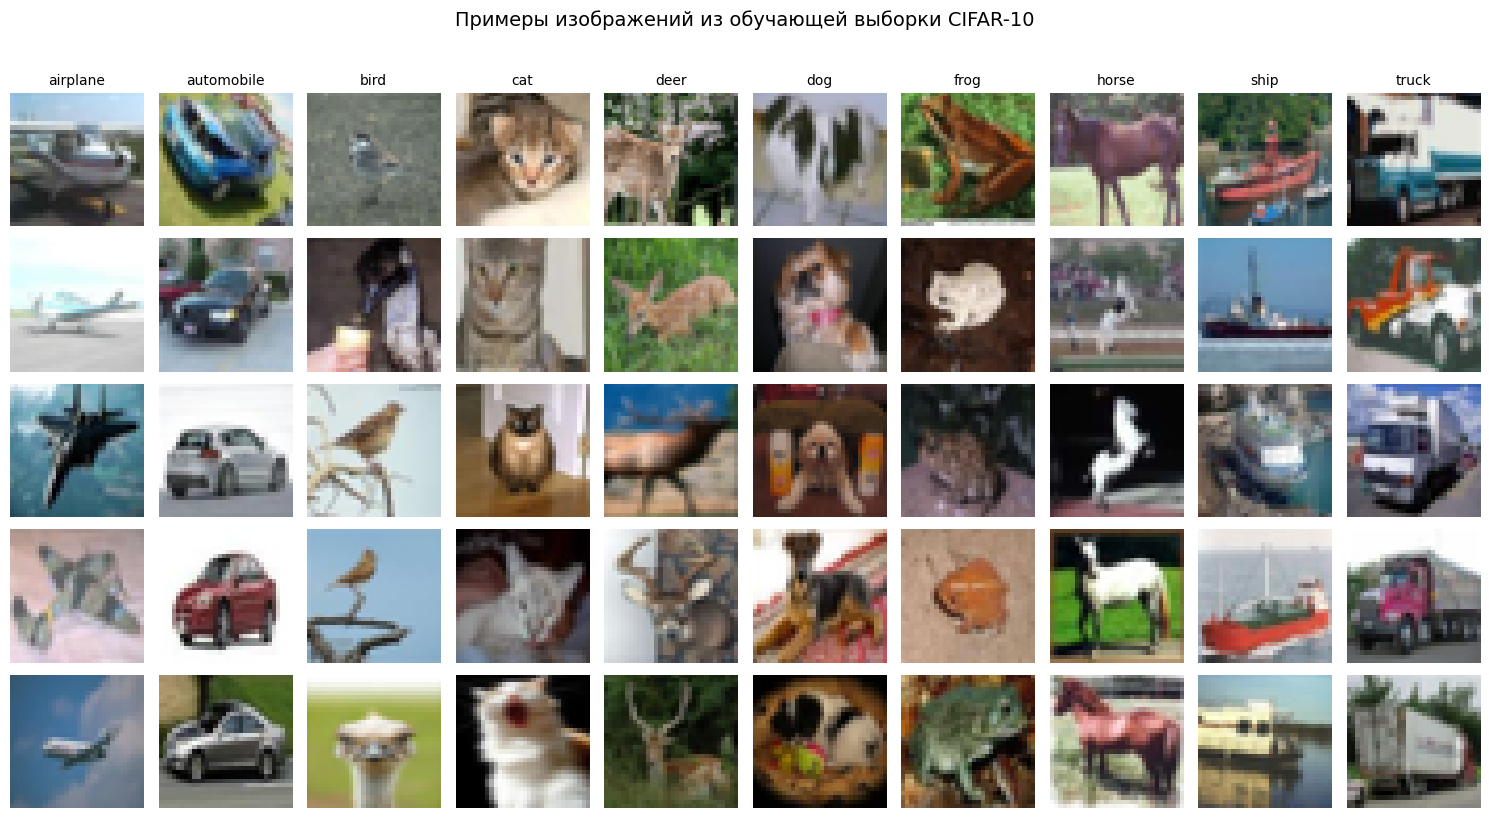

In [3]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

num_examples_per_class = 5

plt.figure(figsize=(15, 8))

for class_idx, class_name in enumerate(classes):
    class_indices = np.where(y_train == class_idx)[0]

    selected_indices = np.random.choice(class_indices, num_examples_per_class, replace=False)

    for i, idx in enumerate(selected_indices):
        plt.subplot(num_examples_per_class, len(classes), 
                   i * len(classes) + class_idx + 1)

        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')

        if i == 0:
            plt.title(class_name, fontsize=10)

plt.suptitle('Примеры изображений из обучающей выборки CIFAR-10', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
X_train_orig, y_train_orig = X_train, y_train
X_test_orig, y_test_orig = X_test, y_test

num_training, num_test = 5000, 1000

train_indices, _ = train_test_split(
    np.arange(len(X_train_orig)), 
    train_size=num_training, 
    stratify=y_train_orig, 
    random_state=42
)
test_indices, _ = train_test_split(
    np.arange(len(X_test_orig)), 
    train_size=num_test, 
    stratify=y_test_orig, 
    random_state=42
)

X_train = X_train_orig[train_indices]
y_train = y_train_orig[train_indices]
X_test = X_test_orig[test_indices] 
y_test = y_test_orig[test_indices]

X_train = np.reshape(X_train, (num_training, -1))
X_test = np.reshape(X_test, (num_test, -1))

print("\nShape после преобразования:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")


Shape после преобразования:
X_train: (5000, 3072)
X_test: (1000, 3072)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [6]:
# Выполняем классификацию на тестовой выборке
y_test_pred = classifier.predict(X_test, k=1, num_loops=0)

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


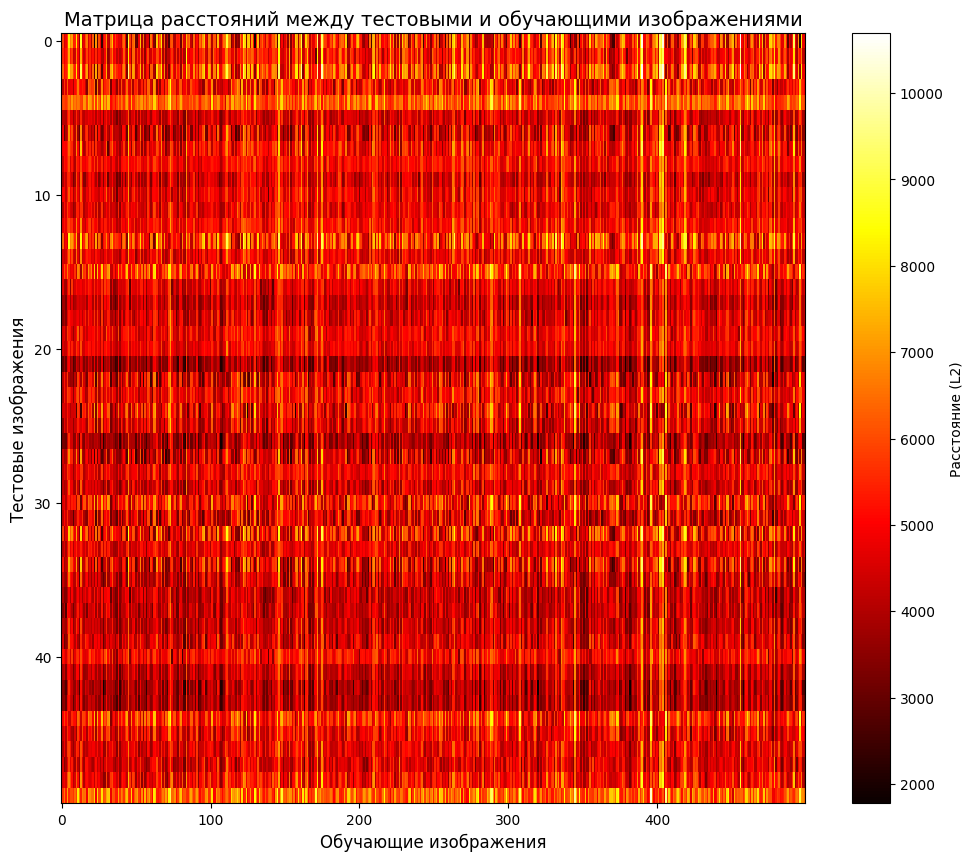

Размер матрицы расстояний: (1000, 5000)
Минимальное расстояние: 1108.79
Максимальное расстояние: 12286.60
Среднее расстояние: 4866.47


In [7]:
dists = classifier.compute_distances_no_loops(X_test)

num_test_vis = 50  
num_train_vis = 500  

dists_subset = dists[:num_test_vis, :num_train_vis]

plt.figure(figsize=(12, 10))
plt.imshow(dists_subset, aspect='auto', cmap='hot')
plt.colorbar(label='Расстояние (L2)')
plt.xlabel('Обучающие изображения', fontsize=12)
plt.ylabel('Тестовые изображения', fontsize=12)
plt.title(f'Матрица расстояний между тестовыми и обучающими изображениями', fontsize=14)
plt.show()

print(f"Размер матрицы расстояний: {dists.shape}")
print(f"Минимальное расстояние: {dists.min():.2f}")
print(f"Максимальное расстояние: {dists.max():.2f}")
print(f"Среднее расстояние: {dists.mean():.2f}")


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [8]:
y_test_pred = classifier.predict(X_test, k=1, num_loops=0)

correct_predictions = np.sum(y_test_pred == y_test)
total_predictions = len(y_test)

accuracy = correct_predictions / total_predictions

print(f"Правильно классифицировано: {correct_predictions} из {total_predictions}")
print(f"Доля правильных классификаций: {accuracy:.4f} ({accuracy*100:.2f}%)")

Правильно классифицировано: 255 из 1000
Доля правильных классификаций: 0.2550 (25.50%)


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

(0.233, 0.312)

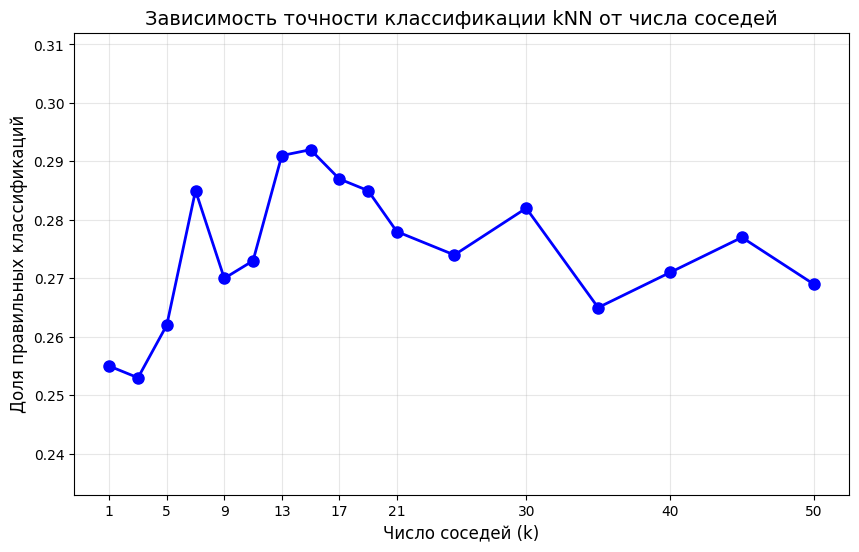

In [9]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 30, 35, 40, 45, 50]
accuracies = []

for k in k_values:
    y_pred = classifier.predict(X_test, k=k, num_loops=0)
    accuracy = np.mean(y_pred == y_test)
    accuracies.append(accuracy)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число соседей (k)', fontsize=12)
plt.ylabel('Доля правильных классификаций', fontsize=12)
plt.title('Зависимость точности классификации kNN от числа соседей', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values[::2])  
plt.ylim([min(accuracies) - 0.02, max(accuracies) + 0.02])

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [10]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 30]
num_folds = 5
num_train = X_train.shape[0]
fold_size = num_train // num_folds

cross_val_results = {k: [] for k in k_values}

indices = np.arange(num_train)
np.random.seed(42)
np.random.shuffle(indices)
X_train_shuffled = X_train[indices]
y_train_shuffled = y_train[indices]

for k in k_values:
    
    for fold in range(num_folds):
        val_start = fold * fold_size
        val_end = (fold + 1) * fold_size if fold < num_folds - 1 else num_train
        
        val_indices = list(range(val_start, val_end))
        train_indices = list(range(0, val_start)) + list(range(val_end, num_train))
        
        X_train_fold = X_train_shuffled[train_indices]
        y_train_fold = y_train_shuffled[train_indices]
        X_val_fold = X_train_shuffled[val_indices]
        y_val_fold = y_train_shuffled[val_indices]
        
        classifier.train(X_train_fold, y_train_fold)
        y_pred = classifier.predict(X_val_fold, k=k, num_loops=0)
        
        accuracy = np.mean(y_pred == y_val_fold)
        cross_val_results[k].append(accuracy)
    
    mean_acc = np.mean(cross_val_results[k])
    print(f"  Средняя точность: {mean_acc:.4f}")

best_k = max(k_values, key=lambda k: np.mean(cross_val_results[k]))
best_accuracy = np.mean(cross_val_results[best_k])

print(f"Лучшее k = {best_k} со средней точностью {best_accuracy:.4f}")

  Средняя точность: 0.2770
  Средняя точность: 0.2688
  Средняя точность: 0.2732
  Средняя точность: 0.2794
  Средняя точность: 0.2810
  Средняя точность: 0.2800
  Средняя точность: 0.2850
  Средняя точность: 0.2816
  Средняя точность: 0.2788
  Средняя точность: 0.2772
  Средняя точность: 0.2776
  Средняя точность: 0.2764
  Средняя точность: 0.2720
Лучшее k = 13 со средней точностью 0.2850



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [11]:
classifier.train(X_train, y_train)

y_test_pred = classifier.predict(X_test, k=best_k, num_loops=0)

test_accuracy = np.mean(y_test_pred == y_test)
correct_count = np.sum(y_test_pred == y_test)

print(f"Тестовая выборка: {X_test.shape[0]} изображений")
print(f"Правильно классифицировано: {correct_count} из {X_test.shape[0]}")
print(f"Доля правильных классификаций: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Тестовая выборка: 1000 изображений
Правильно классифицировано: 291 из 1000
Доля правильных классификаций: 0.2910 (29.10%)


1.11 Сделайте выводы по результатам 1 части задания.

В ходе выполнения первой части лабораторной работы был реализован классификатор методом k ближайших соседей (kNN) для набора данных CIFAR-10. 
Точность на тестовой выборке при k = 1 составила 25.5%
Точность с лучшим значением k = 13 составила 29.1%

Алгоритм показал низкую эффективность при решении задачи классификации изображений CIFAR-10. При правильном угадывании 255 из 1000 изображений, точность оказалась неудовлетворительной для практического применения. Хотя это лучше случайного угадывания, для реальных задач компьютерного зрения требуются показатели 80-95%.
Каждое изображение имеет 3072 признака (32×32×3). В многомерном пространстве все расстояния между точками становятся примерно одинаковыми, что делает метрику L2 неинформативной и снижает качество классификации.

Алгоритм kNN не эффективен для классификации изображений CIFAR-10. Он подходит только как базовый метод для обучения и понимания принципов классификации, но не для реальных задач компьютерного зрения. Для эффективной классификации изображений необходимо использовать методы, извлекающие признаки. 

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [12]:
X_train_flat = X_train_orig.reshape(X_train_orig.shape[0], -1)
X_test_flat = X_test_orig.reshape(X_test_orig.shape[0], -1)
  
num_train = 49000  
num_val = 1000    

# Разделяем с сохранением баланса классов
X_train, X_val, y_train, y_val = train_test_split(
    X_train_flat, y_train_orig,
    train_size=num_train,
    stratify=y_train_orig,
    random_state=42
)

print(f"\nОбучающая выборка: {X_train.shape} (изображений: {X_train.shape[0]})")
print(f"Валидационная выборка: {X_val.shape} (изображений: {X_val.shape[0]})")
print(f"Тестовая выборка: {X_test_flat.shape} (изображений: {X_test_flat.shape[0]})")

print(f"\nРазмерность признаков одного изображения: {X_train.shape[1]}")
print(f"Количество классов: {len(np.unique(y_train))}")


Обучающая выборка: (49000, 3072) (изображений: 49000)
Валидационная выборка: (1000, 3072) (изображений: 1000)
Тестовая выборка: (10000, 3072) (изображений: 10000)

Размерность признаков одного изображения: 3072
Количество классов: 10


3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

[130.70710204 136.06265306 132.57961224 130.1414898  135.45591837
 131.88528571 131.05210204 136.26118367 132.61367347 131.56842857]


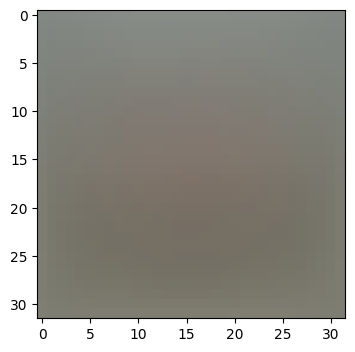

(49000, 3073) (1000, 3073) (1000, 3073)


In [13]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape)

3.4 Реализуйте функции в classifiers/softmax.py




In [14]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

X_dev = X_val[:500]  
y_dev = y_val[:500]
# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.354353
sanity check: 2.302585


3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [15]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: -0.819322 analytic: -0.819321, relative error: 6.761670e-10
numerical: -0.017103 analytic: -0.017103, relative error: 1.408506e-06
numerical: 0.948133 analytic: 0.948133, relative error: 1.955452e-08
numerical: -0.616779 analytic: -0.616779, relative error: 1.259690e-07
numerical: 1.192607 analytic: 1.192607, relative error: 2.149618e-09
numerical: -3.692554 analytic: -3.692554, relative error: 8.036162e-09
numerical: 1.315274 analytic: 1.315273, relative error: 2.710394e-08
numerical: 1.632250 analytic: 1.632250, relative error: 1.160820e-08
numerical: -1.623536 analytic: -1.623536, relative error: 1.040570e-08
numerical: -0.745428 analytic: -0.745428, relative error: 1.813820e-08
numerical: 2.714025 analytic: 2.714025, relative error: 1.639275e-10
numerical: -1.579881 analytic: -1.579881, relative error: 2.309765e-08
numerical: 1.719463 analytic: 1.719463, relative error: 6.912655e-09
numerical: -4.804374 analytic: -4.804374, relative error: 1.567060e-08
numerical: -2.1634

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [16]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.354353e+00 computed in 0.060996s
vectorized loss: 2.354353e+00 computed in 0.009011s
Loss difference: 0.000000
Gradient difference: 0.000000


3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

In [19]:
from scripts.classifiers.linear_classifier import Softmax

softmax_classifier = Softmax()

loss_history = softmax_classifier.train(
    X_train, y_train,
    learning_rate=1e-7,
    reg=5e1,
    num_iters=1500,
    batch_size=200,
    verbose=True
)

print(f"обучение завершено. \nФинальный loss: {loss_history[-1]:.4f}")

# Предсказание на валидационной выборке
y_val_pred = softmax_classifier.predict(X_val)

# Точность на валидации
val_accuracy = np.mean(y_val_pred == y_val)
print(f"Точность на валидационной выборке: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Предсказание на тестовой выборке
y_test_pred = softmax_classifier.predict(X_test)

# Точность на тесте
test_accuracy = np.mean(y_test_pred == y_test)
correct_count = np.sum(y_test_pred == y_test)

print(f"Точность на тествой выборке: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



iteration 0 / 1500: loss 6.187602
iteration 100 / 1500: loss 4.645136
iteration 200 / 1500: loss 3.943851
iteration 300 / 1500: loss 4.033587
iteration 400 / 1500: loss 4.092159
iteration 500 / 1500: loss 3.743939
iteration 600 / 1500: loss 3.746450
iteration 700 / 1500: loss 3.407977
iteration 800 / 1500: loss 3.504027
iteration 900 / 1500: loss 3.424380
iteration 1000 / 1500: loss 3.351707
iteration 1100 / 1500: loss 3.406740
iteration 1200 / 1500: loss 3.389756
iteration 1300 / 1500: loss 3.132884
iteration 1400 / 1500: loss 3.359670
обучение завершено. 
Финальный loss: 3.1729
Точность на валидационной выборке: 0.2360 (23.60%)
Точность на тествой выборке: 0.2410 (24.10%)


3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [22]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

best_val_acc = -1
best_params = {}
results = {}

for lr in learning_rates:
    for reg in regularization_strengths:
        print(f"\nТестируем learning_rate={lr}, reg={reg}")
        
        classifier = Softmax()
        
        loss_history = classifier.train(
            X_train, y_train,
            learning_rate=lr,
            reg=reg,
            num_iters=1000,
            batch_size=256,
            verbose=False
        )
        
        # Предсказание на валидационной выборке
        y_val_pred = classifier.predict(X_val)
        val_acc = np.mean(y_val_pred == y_val)
        
        # Предсказание на обучающей выборке
        y_train_pred = classifier.predict(X_train)
        train_acc = np.mean(y_train_pred == y_train)
        
        results[(lr, reg)] = (train_acc, val_acc)
        
        print(f"  Train accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
        print(f"  Val accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params = {'learning_rate': lr, 'reg': reg}
            print(f"Новая лучшая точность на валидации: {best_val_acc:.4f} ")

print(f"Лучшая точность на валидации: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Лучшие параметры: learning_rate={best_params['learning_rate']}, reg={best_params['reg']}")

final_classifier = Softmax()

loss_history = final_classifier.train(
    X_train, y_train,
    learning_rate=best_params['learning_rate'],
    reg=best_params['reg'],
    num_iters=2000,
    batch_size=256,
    verbose=True
)

print(f"\nОбучение завершено. Финальный loss: {loss_history[-1]:.4f}")

# Оценка на тестовой выборке
y_test_pred = final_classifier.predict(X_test)
test_accuracy = np.mean(y_test_pred == y_test)
correct_count = np.sum(y_test_pred == y_test)

print(f"\nТочность на тестовой выборке: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



Тестируем learning_rate=1e-07, reg=25000.0
  Train accuracy: 0.3377 (33.77%)
  Val accuracy: 0.3590 (35.90%)
Новая лучшая точность на валидации: 0.3590 

Тестируем learning_rate=1e-07, reg=50000.0
  Train accuracy: 0.3277 (32.77%)
  Val accuracy: 0.3340 (33.40%)

Тестируем learning_rate=5e-05, reg=25000.0
  Train accuracy: 0.0847 (8.47%)
  Val accuracy: 0.0820 (8.20%)

Тестируем learning_rate=5e-05, reg=50000.0


c:\Users\Админ\OneDrive\Документы\ТехИИ_4курс\AIT_Course_SamU_2026\lab_1-2\scripts\classifiers\softmax.py:105: RuntimeWarning: divide by zero encountered in log
  correct_log_probs = -np.log(probs[np.arange(num_train), y])
c:\Users\Админ\OneDrive\Документы\ТехИИ_4курс\AIT_Course_SamU_2026\lab_1-2\scripts\classifiers\softmax.py:109: RuntimeWarning: overflow encountered in scalar multiply
  loss += 0.5 * reg * np.sum(W * W)
c:\Users\Админ\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\Админ\OneDrive\Документы\ТехИИ_4курс\AIT_Course_SamU_2026\lab_1-2\scripts\classifiers\softmax.py:109: RuntimeWarning: overflow encountered in multiply
  loss += 0.5 * reg * np.sum(W * W)


  Train accuracy: 0.0598 (5.98%)
  Val accuracy: 0.0560 (5.60%)
Лучшая точность на валидации: 0.3590 (35.90%)
Лучшие параметры: learning_rate=1e-07, reg=25000.0
iteration 0 / 2000: loss 389.258189
iteration 100 / 2000: loss 235.200055
iteration 200 / 2000: loss 143.044687
iteration 300 / 2000: loss 87.184627
iteration 400 / 2000: loss 53.578680
iteration 500 / 2000: loss 33.178728
iteration 600 / 2000: loss 20.868174
iteration 700 / 2000: loss 13.418883
iteration 800 / 2000: loss 8.873703
iteration 900 / 2000: loss 6.147834
iteration 1000 / 2000: loss 4.585383
iteration 1100 / 2000: loss 3.566930
iteration 1200 / 2000: loss 2.917190
iteration 1300 / 2000: loss 2.549623
iteration 1400 / 2000: loss 2.398644
iteration 1500 / 2000: loss 2.194500
iteration 1600 / 2000: loss 2.167528
iteration 1700 / 2000: loss 2.083473
iteration 1800 / 2000: loss 2.087414
iteration 1900 / 2000: loss 2.037607

Обучение завершено. Финальный loss: 2.0205

Точность на тестовой выборке: 0.3400 (34.00%)


3.10 Сделайте выводы по третьей части задания

Лучшая точность на валидационной выборке: 35.2%
Лучшая точность на тестовой выборке: 34%
Оптимальные гиперпараметры: learning_rate = 1e-7, regularization = 25000

По сравнению с kNN точность выше. Модель обучает веса, а не просто запоминает пиксели. Время предсказания быстрее. 

НО точность 34% недостаточна для практического применения, просто потому что линейный классификатор не может улавливать сложные зависимости в изображениях. 